In [1]:
import os
import nibabel as nib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.ndimage import zoom, gaussian_filter
import re

# --- Configuration ---
RELOAD = False  # Set to True to re-process; False to load from saved files
SAVE_DIR = "/media/mts_dbs/processed_arrays"
MSW_CSV = '/data/Ali/RadDBS-QSM/data/docs/dbs_03292024.csv'
CHH_CSV = '/media/mts_dbs/chh/xlsx/chh_subjects_table1_20240729.csv'
UNLABELED_CHH_PATH = "/media/mts_dbs/chh/nii/q" 
TARGET_SHAPE = (64, 64, 72)

os.makedirs(SAVE_DIR, exist_ok=True)

def get_clinical_metadata():
    clinical_dict, label_map = {}, {}
    try:
        df_chh = pd.read_csv(CHH_CSV, header=None)
        for _, row in df_chh.iloc[2:].iterrows():
            if pd.isna(row[0]): continue 
            sub_id = str(int(float(row[0])))
            vec = [row[1], row[2], row[3], row[4], row[9], row[10]]
            clinical_dict[sub_id] = np.nan_to_num(np.array(vec, dtype=np.float32))
            off_p, post_p = pd.to_numeric(row[9], errors='coerce'), pd.to_numeric(row[11], errors='coerce') 
            label_map[sub_id] = 1 if (not pd.isna(off_p) and not pd.isna(post_p) and off_p > 0 and (off_p - post_p)/off_p >= 0.30) else (0 if not pd.isna(off_p) and not pd.isna(post_p) else -1)
    except Exception as e: print(f"!! CHH CSV Error: {e}")
    try:
        df_msw = pd.read_csv(MSW_CSV, header=1)
        df_msw.columns = [str(c).strip().replace('\n', ' ') for c in df_msw.columns]
        for _, row in df_msw.iterrows():
            raw_id = row.get('CORNELL ID')
            if pd.isna(raw_id): continue
            sub_id = str(int(float(raw_id)))
            sex_num = 1 if 'f' in str(row.get('Sex')).lower() or '1' in str(row.get('Sex')) else 0
            vec = [row.get('Age'), sex_num, row.get('Disease Duration (year)'), row.get('pre op levadopa equivalent dose (mg)'), row.get('OFF (pre-dbs updrs)'), row.get('ON (pre-dbs updrs)')]
            clinical_dict[sub_id] = np.nan_to_num(np.array(vec, dtype=np.float32))
            off_p, post_p = pd.to_numeric(row.get('OFF (pre-dbs updrs)'), errors='coerce'), pd.to_numeric(row.get('OFF meds ON stim 6mo'), errors='coerce')
            label_map[sub_id] = 1 if (not pd.isna(off_p) and not pd.isna(post_p) and off_p > 0 and (off_p - post_p)/off_p >= 0.30) else (0 if not pd.isna(off_p) and not pd.isna(post_p) else -1)
    except Exception as e: print(f"!! MSW CSV Error: {e}")
    return clinical_dict, label_map

def context_matched_loader(nii_dir, seg_dir, clin_dict, label_map, mode='CHH', split_name="Split", rel_consensus=None):
    processed_vols, subject_ids, clinical_vecs, labels = [], [], [], []
    rel_coords = []
    preview_shown = False 
    
    all_files = sorted([f for f in os.listdir(nii_dir) if f.endswith('.nii.gz')])
    print(f"\n>>> {split_name}: {len(all_files)} files.")

    for f in tqdm(all_files):
        try:
            match = re.search(r'\d+', f); sub_id_int = int(match.group()); sub_id_str = str(sub_id_int)
            img_obj = nib.as_closest_canonical(nib.load(os.path.join(nii_dir, f)))
            img_data = img_obj.get_fdata()
            full_shape = np.array(img_data.shape)

            if rel_consensus is not None:
                cz, cy, cx = (rel_consensus * full_shape).astype(int)
            else:
                mask_name = f"seg_{sub_id_int:02d}.nii.gz" if mode == 'MSW' else f"{sub_id_int:02d}_roi_combined.nii"
                mask_path = os.path.join(seg_dir, mask_name)
                if not os.path.exists(mask_path) and os.path.exists(mask_path + ".gz"): mask_path += ".gz"
                if not os.path.exists(mask_path):
                    mask_path = os.path.join(seg_dir, mask_name.replace(f"{sub_id_int:02d}", str(sub_id_int)))
                    if not os.path.exists(mask_path) and os.path.exists(mask_path + ".gz"): mask_path += ".gz"
                if not os.path.exists(mask_path): continue 

                mask_obj = nib.as_closest_canonical(nib.load(mask_path))
                mask_data = mask_obj.get_fdata()
                u_labels = set(np.unique(mask_data))
                anchors = [1,2,3,4] if (3 in u_labels or 4 in u_labels) else ([5,6,7,8] if (7 in u_labels or 8 in u_labels) else [l for l in u_labels if l > 0])
                anchor_mask = np.isin(mask_data, anchors)
                if np.sum(anchor_mask) == 0: continue

                coords = np.argwhere(anchor_mask > 0)
                abs_center = coords.mean(axis=0)
                cz, cy, cx = abs_center.astype(int)
                rel_coords.append(abs_center / full_shape)

            if mode == 'MSW':
                hz, hy, hx = 72, 72, 80 
                raw_crop = img_data[max(0, cz-hz):cz+hz, max(0, cy-hy):cy+hy, max(0, cx-hx):cx+hx]
                smoothed = gaussian_filter(raw_crop, sigma=0.6)
                factors = (TARGET_SHAPE[0]/raw_crop.shape[0], TARGET_SHAPE[1]/raw_crop.shape[1], TARGET_SHAPE[2]/raw_crop.shape[2])
                final = zoom(smoothed, factors, order=3)
            else:
                hz, hy, hx = 32, 32, 36
                final = img_data[max(0, cz-hz):cz+hz, max(0, cy-hy):cy+hy, max(0, cx-hx):cx+hx]

            if final.shape != TARGET_SHAPE:
                canvas = np.zeros(TARGET_SHAPE)
                zs, ys, xs = [min(a, b) for a, b in zip(final.shape, TARGET_SHAPE)]
                canvas[:zs, :ys, :xs] = final[:zs, :ys, :xs]
                final = canvas

            if not preview_shown:
                plt.figure(figsize=(4, 4))
                plt.imshow(np.rot90(final[:, :, TARGET_SHAPE[2]//2]), cmap='gray', vmin=-250, vmax=250)
                plt.title(f"MATCHED CONTEXT: {split_name}\nSub: {sub_id_str}")
                plt.axis('off'); plt.show()
                preview_shown = True

            final = np.clip(final, -250.0, 250.0) / 250.0
            processed_vols.append(final.flatten().astype(np.float32))
            subject_ids.append(sub_id_str); clinical_vecs.append(clin_dict.get(sub_id_str, np.zeros(6))); labels.append(label_map.get(sub_id_str, -1))
        except: continue
    return np.array(processed_vols), subject_ids, np.array(clinical_vecs), labels, rel_coords

def save_ds(path, X, ids, V, y):
    np.savez_compressed(path, X=X, ids=ids, V=V, y=y)
    print(f"Saved: {path}")

def load_ds(path):
    data = np.load(path, allow_pickle=True)
    return data['X'], list(data['ids']), data['V'], list(data['y'])

# --- EXECUTE ---
p_lab = os.path.join(SAVE_DIR, "ds_lab.npz")
p_msw = os.path.join(SAVE_DIR, "ds_msw.npz")
p_un = os.path.join(SAVE_DIR, "ds_un.npz")

if RELOAD or not all(os.path.exists(p) for p in [p_lab, p_msw, p_un]):
    print(">>> Processing datasets (Reload=True)...")
    clin_dict, label_map = get_clinical_metadata()

    X_lab, ids_lab, V_lab, y_lab, _ = context_matched_loader('/media/mts_dbs/chh/nii/qsm/', '/media/mts_dbs/chh/nii/roi/', clin_dict, label_map, 'CHH', "CHH Labeled")
    X_msw, ids_msw, V_msw, y_msw, msw_rel = context_matched_loader('/media/mts_dbs/dbs/all/nii/qsm_115/im', '/media/mts_dbs/dbs/all/nii/seg_ps/', clin_dict, label_map, 'MSW', "MSW")
    
    avg_rel_center = np.mean(msw_rel, axis=0)
    X_un, ids_un, V_un, y_un, _ = context_matched_loader(UNLABELED_CHH_PATH, '/media/mts_dbs/chh/nii/roi/', clin_dict, label_map, 'CHH', "CHH Unlabeled", rel_consensus=avg_rel_center)

    save_ds(p_lab, X_lab, ids_lab, V_lab, y_lab)
    save_ds(p_msw, X_msw, ids_msw, V_msw, y_msw)
    save_ds(p_un, X_un, ids_un, V_un, y_un)
else:
    print(">>> Loading datasets from disk (Reload=False)...")
    X_lab, ids_lab, V_lab, y_lab = load_ds(p_lab)
    X_msw, ids_msw, V_msw, y_msw = load_ds(p_msw)
    X_un, ids_un, V_un, y_un = load_ds(p_un)

print("\nDone. Datasets ready.")

>>> Loading datasets from disk (Reload=False)...

Done. Datasets ready.


--- Building Sharp Template (N=20) ---
Pass 1...


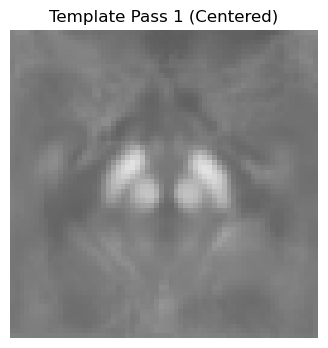

Pass 2...


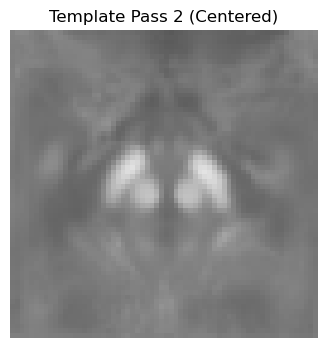


>>> Aligning MSW Dataset...
Registering 109 subjects...
  Progress: 25/109
  Progress: 50/109
  Progress: 75/109
  Progress: 100/109

>>> Aligning CHH Labeled Dataset...
Registering 37 subjects...
  Progress: 25/37

>>> Aligning CHH Unlabeled Dataset...
Registering 3 subjects...

Alignment Complete. X_msw_reg, X_lab_reg, and X_un_reg are ready for PCA.


In [2]:
import ants
import numpy as np
import matplotlib.pyplot as plt

def build_safe_template(X_flat, target_shape=(64, 64, 72), n_debug=20):
    """
    Creates a study-specific template using a subset of subjects.
    Uses Nearest Neighbor to preserve your original -1 to 1 intensity scaling.
    """
    print(f"--- Building Sharp Template (N={n_debug}) ---")
    vols = X_flat[:n_debug].reshape(-1, *target_shape)
    
    # Initialize with the first subject's patch
    current_template_np = vols[0]
    
    for i in range(2):
        print(f"Pass {i+1}...")
        warped_list = []
        ref_ants = ants.from_numpy(current_template_np.astype('float32'))
        
        for idx in range(n_debug):
            moving = ants.from_numpy(vols[idx].astype('float32'))
            # Calculate Rigid transform
            reg = ants.registration(fixed=ref_ants, moving=moving, type_of_transform='Rigid')
            
            # Apply transform with NN interpolation to keep intensities pure
            warped = ants.apply_transforms(fixed=ref_ants, moving=moving, 
                                           transformlist=reg['fwdtransforms'],
                                           interpolation='nearestNeighbor')
            warped_list.append(warped.numpy())
            
        # Update template using standard NumPy mean
        current_template_np = np.mean(warped_list, axis=0)
        
        # Immediate visual feedback
        plt.figure(figsize=(4,4))
        plt.imshow(np.rot90(current_template_np[:, :, target_shape[2]//2]), 
                   cmap='gray', vmin=-1.0, vmax=1.0)
        plt.title(f"Template Pass {i+1} (Centered)")
        plt.axis('off'); plt.show()

    return ants.from_numpy(current_template_np.astype('float32'))

def apply_safe_alignment(X_flat, template_ants, target_shape=(64, 64, 72)):
    """
    Registers a flattened array to a template and returns a flattened aligned array.
    """
    aligned_data = []
    print(f"Registering {len(X_flat)} subjects...")
    
    for i in range(len(X_flat)):
        vol = X_flat[i].reshape(target_shape)
        moving = ants.from_numpy(vol.astype('float32'))
        
        # Get registration to the sharp template
        reg = ants.registration(fixed=template_ants, moving=moving, type_of_transform='Rigid')
        
        # Warp the image
        warped = ants.apply_transforms(fixed=template_ants, moving=moving, 
                                       transformlist=reg['fwdtransforms'],
                                       interpolation='nearestNeighbor')
        
        aligned_data.append(warped.numpy().flatten())
        
        if (i + 1) % 25 == 0: 
            print(f"  Progress: {i + 1}/{len(X_flat)}")
            
    return np.array(aligned_data)

# --- EXECUTION ---

# 1. Create the template from MSW data
final_template_ants = build_safe_template(X_msw, n_debug=20)

# 2. Align all datasets to this new standard space
print("\n>>> Aligning MSW Dataset...")
X_msw_reg = apply_safe_alignment(X_msw, final_template_ants)

print("\n>>> Aligning CHH Labeled Dataset...")
X_lab_reg = apply_safe_alignment(X_lab, final_template_ants)

print("\n>>> Aligning CHH Unlabeled Dataset...")
X_un_reg  = apply_safe_alignment(X_un,  final_template_ants)

print("\nAlignment Complete. X_msw_reg, X_lab_reg, and X_un_reg are ready for PCA.")

--- Masked Stability Flow ---
Masking active: Focusing on top 20% voxels (58983 total)


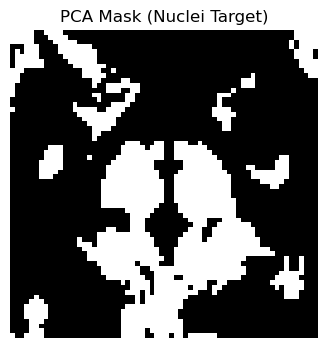

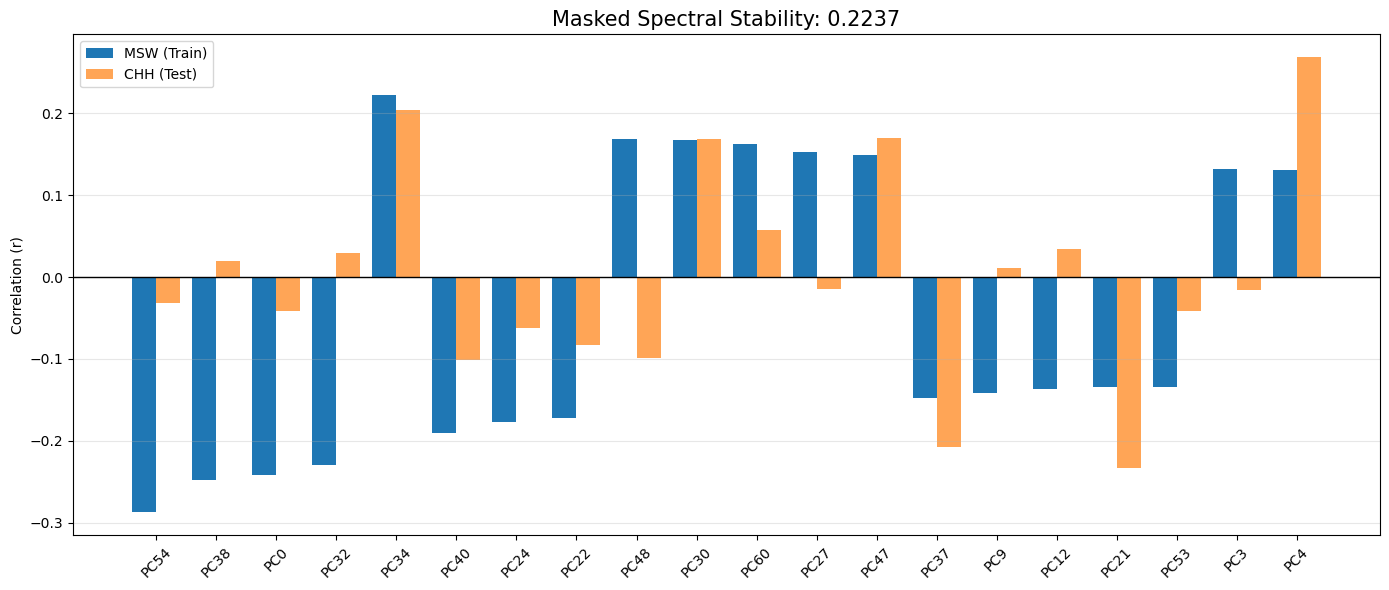

Overall Stability: 0.2237
SUCCESS: Harmonization improved generalizability.


In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.stats import pointbiserialr
from util import seed_everything
seed_everything(0)
def perform_masked_stability_analysis(X_train_reg, y_train, X_test_reg, y_test, template_ants, 
                                     target_shape=(64, 64, 72), percentile=80, n_components=64):
    """
    Consolidated Workflow: 
    1. Masking (targeting nuclei)
    2. Z-Scoring (harmonizing sites)
    3. PCA Generalization (MSW -> CHH)
    4. Stability Check
    """
    # 1. Create the Analysis Mask from Template (Focus on Paramagnetic Iron)
    template_np = template_ants.numpy()
    thresh = np.percentile(template_np, percentile)
    mask_3d = template_np > thresh
    mask_flat = mask_3d.flatten()
    
    print(f"--- Masked Stability Flow ---")
    print(f"Masking active: Focusing on top {100-percentile}% voxels ({np.sum(mask_flat)} total)")
    
    # Visual check of the mask
    mid_z = target_shape[2] // 2
    plt.figure(figsize=(4, 4))
    plt.imshow(np.rot90(mask_3d[:, :, mid_z]), cmap='bone')
    plt.title("PCA Mask (Nuclei Target)")
    plt.axis('off'); plt.show()

    # 2. Extract masked data
    X_tr_m = X_train_reg[:, mask_flat]
    X_te_m = X_test_reg[:, mask_flat]

    # 3. Subject-wise Z-scoring (Site Harmonization)
    def zscore(X):
        m = np.mean(X, axis=1, keepdims=True)
        s = np.std(X, axis=1, keepdims=True) + 1e-8
        return (X - m) / s

    X_tr_norm = zscore(X_tr_m)
    X_te_norm = zscore(X_te_m)

    # 4. PCA Flow
    pca = PCA(n_components=n_components, whiten=True)
    X_tr_pca = pca.fit_transform(X_tr_norm)
    X_te_pca = pca.transform(X_te_norm)

    # 5. Correlation Coefficients
    train_corrs = [np.nan_to_num(pointbiserialr(y_train, X_tr_pca[:, i])[0]) for i in range(n_components)]
    test_corrs = [np.nan_to_num(pointbiserialr(y_test, X_te_pca[:, i])[0]) for i in range(n_components)]
    
    stability = np.corrcoef(train_corrs, test_corrs)[0, 1]

    # 6. Visualization
    top_n = min(20, n_components)
    df_train = pd.DataFrame({'PC': range(n_components), 'Corr': train_corrs})
    top_idx = df_train.reindex(df_train.Corr.abs().sort_values(ascending=False).index).head(top_n)['PC'].values

    tr_vals = [train_corrs[i] for i in top_idx]
    te_vals = [test_corrs[i] for i in top_idx]

    plt.figure(figsize=(14, 6))
    x = np.arange(top_n)
    plt.bar(x - 0.2, tr_vals, 0.4, label='MSW (Train)', color='tab:blue')
    plt.bar(x + 0.2, te_vals, 0.4, label='CHH (Test)', color='tab:orange', alpha=0.7)
    
    plt.xticks(x, [f"PC{i}" for i in top_idx], rotation=45)
    plt.axhline(0, color='black', linewidth=1)
    plt.title(f'Masked Spectral Stability: {stability:.4f}', fontsize=15)
    plt.ylabel('Correlation (r)')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout(); plt.show()

    # Final Output Status
    print(f"Overall Stability: {stability:.4f}")
    if stability < 0.1:
        print("ALERT: Low stability. The biological signal may be too weak or labels too noisy.")
    else:
        print("SUCCESS: Harmonization improved generalizability.")

    return stability, mask_flat

# --- EXECUTE ---
mask_tr = np.array(y_msw) >= 0
mask_te = np.array(y_lab) >= 0

final_stability, mask_flat = perform_masked_stability_analysis(
    X_msw_reg[mask_tr], np.array(y_msw)[mask_tr],
    X_lab_reg[mask_te], np.array(y_lab)[mask_te],
    final_template_ants
)

In [64]:
seed_everything(0)
def perform_sequence_stability_analysis(X_train_reg, y_train, X_test_reg, y_test, template_ants, 
                                        target_shape=(64, 64, 72), percentile=90, n_components=64):
    """
    Sequence-Aware Stability:
    1. Reshapes 3D volumes into sequences of slices.
    2. Focuses only on the Z-range where the nuclei are present.
    3. Computes stability on the features the Transformer actually receives.
    """
    # 1. Identify the Z-range where the iron is (from the template)
    template_np = template_ants.numpy()
    z_intensities = np.sum(template_np, axis=(0, 1))
    # Pick slices that are in the top 20% of total iron intensity
    valid_z = np.where(z_intensities > np.percentile(z_intensities, 80))[0]
    print(f"Analyzing sequence stability across slices: {valid_z.min()} to {valid_z.max()}")

    # 2. Reshape data to (Subjects * Slices, 4096)
    # This mimics the 'every slice' input your Transformer gets
    def to_slice_sequence(X):
        X_res = X.reshape(-1, 72, 4096)
        X_seq = X_res[:, valid_z, :] 
        return X_seq.reshape(-1, 4096)

    X_tr_seq = to_slice_sequence(X_train_reg)
    X_te_seq = to_slice_sequence(X_test_reg)
    
    # Expand labels to match the number of slices per subject
    y_tr_seq = np.repeat(y_train, len(valid_z))
    y_te_seq = np.repeat(y_test, len(valid_z))

    # 3. Create a 2D Mask based on the average of those "iron" slices
    template_slice = np.mean(template_np[:, :, valid_z], axis=2)
    thresh = np.percentile(template_slice, percentile)
    mask_flat = (template_slice > thresh).flatten()

    # 4. Extract & Harmonize
    X_tr_m = X_tr_seq[:, mask_flat]
    X_te_m = X_te_seq[:, mask_flat]

    def zscore(X):
        m = np.mean(X, axis=1, keepdims=True)
        s = np.std(X, axis=1, keepdims=True) + 1e-8
        return (X - m) / s

    X_tr_norm = zscore(X_tr_m)
    X_te_norm = zscore(X_te_m)

    # 5. PCA
    pca = PCA(n_components=n_components, whiten=True)
    X_tr_pca = pca.fit_transform(X_tr_norm)
    X_te_pca = pca.transform(X_te_norm)

    # 6. Stability Check
    train_corrs = [np.nan_to_num(pointbiserialr(y_tr_seq, X_tr_pca[:, i])[0]) for i in range(n_components)]
    test_corrs = [np.nan_to_num(pointbiserialr(y_te_seq, X_te_pca[:, i])[0]) for i in range(n_components)]
    
    stability = np.corrcoef(train_corrs, test_corrs)[0, 1]
    print(f"Sequence Spectral Stability: {stability:.4f}")
    
    return stability

# --- EXECUTE ---
final_stability = perform_sequence_stability_analysis(
    X_msw_reg[mask_tr], np.array(y_msw)[mask_tr],
    X_lab_reg[mask_te], np.array(y_lab)[mask_te],
    final_template_ants
)

def check_noise_floor(X_train_reg, y_train, X_test_reg, y_test, start_z=0, end_z=20):
    # Mimic the Transformer input for the 'junk' slices
    def get_junk(X, y):
        X_res = X.reshape(-1, 72, 4096)
        X_seq = X_res[:, start_z:end_z, :].reshape(-1, 4096)
        y_seq = np.repeat(y, (end_z - start_z))
        return X_seq, y_seq

    X_tr_j, y_tr_j = get_junk(X_train_reg, y_train)
    X_te_j, y_te_j = get_junk(X_test_reg, y_test)
    
    # Run PCA on junk
    pca = PCA(n_components=10, whiten=True).fit(X_tr_j)
    X_tr_pca = pca.transform(X_tr_j)
    X_te_pca = pca.transform(X_te_j)
    
    # Check correlations
    tr_corrs = [np.nan_to_num(pointbiserialr(y_tr_j, X_tr_pca[:, i])[0]) for i in range(10)]
    te_corrs = [np.nan_to_num(pointbiserialr(y_te_j, X_te_pca[:, i])[0]) for i in range(10)]
    
    stability = np.corrcoef(tr_corrs, te_corrs)[0, 1]
    print(f"Stability in 'Junk' Slices ({start_z}-{end_z}): {stability:.4f}")

# Execute correctly
check_noise_floor(
    X_msw_reg[mask_tr], np.array(y_msw)[mask_tr],
    X_lab_reg[mask_te], np.array(y_lab)[mask_te]
)

Analyzing sequence stability across slices: 40 to 54
Sequence Spectral Stability: 0.2311
Stability in 'Junk' Slices (0-20): -0.0023


In [65]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from scipy.stats import pointbiserialr

def perform_sequence_stability_analysis(X_train_reg, y_train, X_test_reg, y_test, template_ants, 
                                        target_shape=(64, 64, 72), percentile=98, n_components=64):
    template_np = template_ants.numpy()
    z_intensities = np.sum(template_np, axis=(0, 1))
    valid_z = np.where(z_intensities > np.percentile(z_intensities, 80))[0]
    
    def to_slice_sequence(X):
        X_res = X.reshape(-1, 72, 4096)
        X_seq = X_res[:, valid_z, :] 
        return X_seq.reshape(-1, 4096)

    X_tr_seq = to_slice_sequence(X_train_reg)
    X_te_seq = to_slice_sequence(X_test_reg)
    y_tr_seq = np.repeat(y_train, len(valid_z))
    y_te_seq = np.repeat(y_test, len(valid_z))

    template_slice = np.mean(template_np[:, :, valid_z], axis=2)
    mask_flat = (template_slice > np.percentile(template_slice, percentile)).flatten()

    def zscore(X):
        m = np.mean(X, axis=1, keepdims=True)
        s = np.std(X, axis=1, keepdims=True) + 1e-8
        return (X - m) / s

    X_tr_norm = zscore(X_tr_seq[:, mask_flat])
    X_te_norm = zscore(X_te_seq[:, mask_flat])

    pca = PCA(n_components=n_components, whiten=True)
    X_tr_pca = pca.fit_transform(X_tr_norm)
    X_te_pca = pca.transform(X_te_norm)

    # Store full results (r, p)
    train_results = [pointbiserialr(y_tr_seq, X_tr_pca[:, i]) for i in range(n_components)]
    test_results = [pointbiserialr(y_te_seq, X_te_pca[:, i]) for i in range(n_components)]
    
    train_corrs = [res[0] for res in train_results]
    test_corrs = [res[0] for res in test_results]
    stability = np.corrcoef(train_corrs, test_corrs)[0, 1]
    
    # Create detailed DataFrame
    stats_df = pd.DataFrame({
        'PC': range(n_components),
        'MSW_r': train_corrs,
        'MSW_p': [res[1] for res in train_results],
        'CHH_r': test_corrs,
        'CHH_p': [res[1] for res in test_results]
    })
    
    return stability, stats_df, pca

# --- EXECUTE ---
mask_tr = np.array(y_msw) >= 0
mask_te = np.array(y_lab) >= 0
print("\n WITH 98th PERCENTILE")
stability, stats_df, pca = perform_sequence_stability_analysis(
    X_msw_reg[mask_tr], np.array(y_msw)[mask_tr],
    X_lab_reg[mask_te], np.array(y_lab)[mask_te],
    final_template_ants
)

# Sort by strongest training correlation (absolute value)
stats_df['MSW_abs_r'] = stats_df['MSW_r'].abs()
sorted_stats = stats_df.sort_values('MSW_abs_r', ascending=False).drop(columns=['MSW_abs_r'])

print(f"Overall Sequence Stability (R-of-R): {stability:.4f}")
print("\nTop 10 Components by Training Strength (MSW):")
print(sorted_stats.head(10).to_string(index=False))

# Optional: Filter for components significant in BOTH sites
significant_both = sorted_stats[(sorted_stats['MSW_p'] < 0.05) & (sorted_stats['CHH_p'] < 0.05)]
if not significant_both.empty:
    print("\nComponents Significant in BOTH sites (p < 0.05):")
    print(significant_both.to_string(index=False))
else:
    print("\nNo components reached p < 0.05 in both sites simultaneously.")

print("\n WITH 90th PERCENTILE")
stability, stats_df, pca_90 = perform_sequence_stability_analysis(
    X_msw_reg[mask_tr], np.array(y_msw)[mask_tr],
    X_lab_reg[mask_te], np.array(y_lab)[mask_te],
    final_template_ants, percentile=90
)

# Sort by strongest training correlation (absolute value)
stats_df['MSW_abs_r'] = stats_df['MSW_r'].abs()
sorted_stats = stats_df.sort_values('MSW_abs_r', ascending=False).drop(columns=['MSW_abs_r'])

print(f"Overall Sequence Stability (R-of-R): {stability:.4f}")
print("\nTop 10 Components by Training Strength (MSW):")
print(sorted_stats.head(10).to_string(index=False))

# Optional: Filter for components significant in BOTH sites
significant_both = sorted_stats[(sorted_stats['MSW_p'] < 0.05) & (sorted_stats['CHH_p'] < 0.05)]
if not significant_both.empty:
    print("\nComponents Significant in BOTH sites (p < 0.05):")
    print(significant_both.to_string(index=False))
else:
    print("\nNo components reached p < 0.05 in both sites simultaneously.")




 WITH 98th PERCENTILE
Overall Sequence Stability (R-of-R): 0.0497

Top 10 Components by Training Strength (MSW):
 PC     MSW_r    MSW_p     CHH_r    CHH_p
 36  0.069192 0.012930  0.022702 0.593566
 42  0.068959 0.013238  0.088134 0.037926
 52  0.058938 0.034289 -0.035561 0.403072
 24  0.044412 0.110855 -0.046465 0.274493
 62  0.044366 0.111223 -0.043225 0.309398
 30 -0.041998 0.131647 -0.096702 0.022705
 51  0.040833 0.142708 -0.067404 0.112704
 56  0.040468 0.146315  0.018786 0.658776
 15 -0.037944 0.173199  0.005399 0.899011
 10 -0.036852 0.185913  0.020025 0.637820

Components Significant in BOTH sites (p < 0.05):
 PC    MSW_r    MSW_p    CHH_r    CHH_p
 42 0.068959 0.013238 0.088134 0.037926

 WITH 90th PERCENTILE
Overall Sequence Stability (R-of-R): 0.2156

Top 10 Components by Training Strength (MSW):
 PC     MSW_r    MSW_p     CHH_r    CHH_p
 36 -0.056382 0.042900 -0.057630 0.175181
 44 -0.053079 0.056663  0.031435 0.459863
 50 -0.049101 0.077916  0.026208 0.537799
 35  0.04885